# Module 10 Practical: Association Rules and FP-Growth

This beginner tutorial uses randomly generated shopping transactions.

You will learn how to:

1. create transaction data;
2. calculate item support;
3. prepare transactions for an FP-tree;
4. construct and print a simple FP-tree;
5. create a conditional pattern base and conditional tree; and
6. calculate association rules using support, confidence and lift.

The random seed is fixed, so the same transactions and results are produced each time.

## 1. Import the required libraries

- `random` creates example transactions.
- `Counter` counts items and itemsets.
- `combinations` creates possible item combinations.
- `pandas` displays results as tables.
- `matplotlib` and `networkx` draw the FP-tree.
- `math.ceil()` converts minimum support into a whole-number transaction count.

In [1]:
!pip install pandas matplotlib networkx -q

import random
import math

from collections import Counter
from itertools import combinations

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 785, in warm_spreadsheet_runtime
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 720, in _warm_feature_flows
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 704, in _warm_collaboration_flows
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/generated/interface/models.py", line 30820, in hydrate_crdt_from_proto
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/rpc/remote.py", line 749, in __call__
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/rpc/client.py", line 150, in call
artifact_tool.rpc.client.RemoteE

## 2. Generate random transaction data

Each transaction represents one customer's shopping basket.

The code also adds several likely shopping patterns:

- customers who buy **Bread** often also buy **Butter**;
- customers who buy **Cereal** often also buy **Milk**; and
- customers who buy **Coffee** often also buy **Milk**.

These patterns give the association-rule method something meaningful to discover.

In [2]:
random.seed(42)

all_items = [
    "Bread",
    "Butter",
    "Milk",
    "Eggs",
    "Cereal",
    "Coffee"
]

transactions = []

for transaction_number in range(60):
    basket = set()

    # Add items using simple probabilities.
    if random.random() < 0.55:
        basket.add("Bread")

    if random.random() < 0.45:
        basket.add("Milk")

    if random.random() < 0.30:
        basket.add("Eggs")

    if random.random() < 0.25:
        basket.add("Cereal")

    if random.random() < 0.20:
        basket.add("Coffee")

    if random.random() < 0.10:
        basket.add("Butter")

    # Add several related purchasing patterns.
    if "Bread" in basket and random.random() < 0.80:
        basket.add("Butter")

    if "Cereal" in basket and random.random() < 0.80:
        basket.add("Milk")

    if "Coffee" in basket and random.random() < 0.65:
        basket.add("Milk")

    # Make sure every transaction contains at least one item.
    if not basket:
        basket.add(random.choice(all_items))

    transactions.append(sorted(basket))

Display the first ten transactions.

In [3]:
transactions_table = pd.DataFrame({
    "Transaction": range(1, len(transactions) + 1),
    "Items": [", ".join(basket) for basket in transactions]
})

transactions_table.head(10)

,Transaction,Items
0,1,"Cereal, Eggs, Milk"
1,2,"Bread, Butter, Cereal, Eggs, Milk"
2,3,"Bread, Butter, Coffee, Milk"
3,4,"Bread, Butter, Cereal, Coffee"
4,5,Bread
5,6,"Butter, Cereal, Eggs, Milk"
6,7,"Bread, Butter, Milk"
7,8,"Cereal, Milk"
8,9,Butter
9,10,"Cereal, Milk"


## 3. Count item support

**Support** is the proportion of transactions that contain an item.

For example, if Bread appears in 30 of 60 transactions:

\[
\text{Support(Bread)} = \frac{30}{60} = 0.50
\]

Here, the minimum support is set to `0.20`, which means an item must appear in at least 20% of transactions.

In [4]:
item_counts = Counter(
    item
    for basket in transactions
    for item in set(basket)
)

minimum_support = 0.20
minimum_count = math.ceil(minimum_support * len(transactions))

item_support_table = pd.DataFrame([
    {
        "Item": item,
        "Count": count,
        "Support": round(count / len(transactions), 3)
    }
    for item, count in item_counts.items()
]).sort_values("Support", ascending=False)

print("Minimum transaction count:", minimum_count)

item_support_table

Minimum transaction count: 12


,Item,Count,Support
2,Milk,39,0.650
3,Bread,36,0.600
4,Butter,30,0.500
0,Cereal,19,0.317
5,Coffee,18,0.300
1,Eggs,12,0.200


## 4. Keep frequent items and order each transaction

FP-Growth first removes items that do not meet the minimum support.

The remaining items are ordered from the most frequent to the least frequent. This consistent order allows transactions with similar prefixes to share the same branches in the FP-tree.

Each shopping basket appears once in our dataset, so every transaction contributes a count of **1**. We therefore do not need a separate `weight` variable.

In [5]:
frequent_items = {
    item: count
    for item, count in item_counts.items()
    if count >= minimum_count
}

global_order = sorted(
    frequent_items,
    key=lambda item: (-frequent_items[item], item)
)

global_rank = {
    item: position
    for position, item in enumerate(global_order)
}

ordered_transactions = []

for basket in transactions:
    filtered_basket = [
        item
        for item in basket
        if item in frequent_items
    ]

    filtered_basket.sort(
        key=lambda item: global_rank[item]
    )

    if filtered_basket:
        ordered_transactions.append(filtered_basket)

print("Frequent-item order:")
print(global_order)

print("\nFirst five ordered transactions:")
for basket in ordered_transactions[:5]:
    print(basket)

Frequent-item order:
['Milk', 'Bread', 'Butter', 'Cereal', 'Coffee', 'Eggs']

First five ordered transactions:
['Milk', 'Cereal', 'Eggs']
['Milk', 'Bread', 'Butter', 'Cereal', 'Eggs']
['Milk', 'Bread', 'Butter', 'Coffee']
['Bread', 'Butter', 'Cereal', 'Coffee']
['Bread']


## 5. Construct and visualise the FP-tree

Each FP-tree node stores:

- an item;
- a count; and
- any child nodes below it.

When two transactions share the same starting items, they share the same branch. The count is increased instead of creating a duplicate branch.

Because every original transaction occurs once, the tree-building function simply adds `1` whenever a transaction passes through a node.

The drawing helper converts the tree into a `networkx` graph. Each box displays the item name and its count.

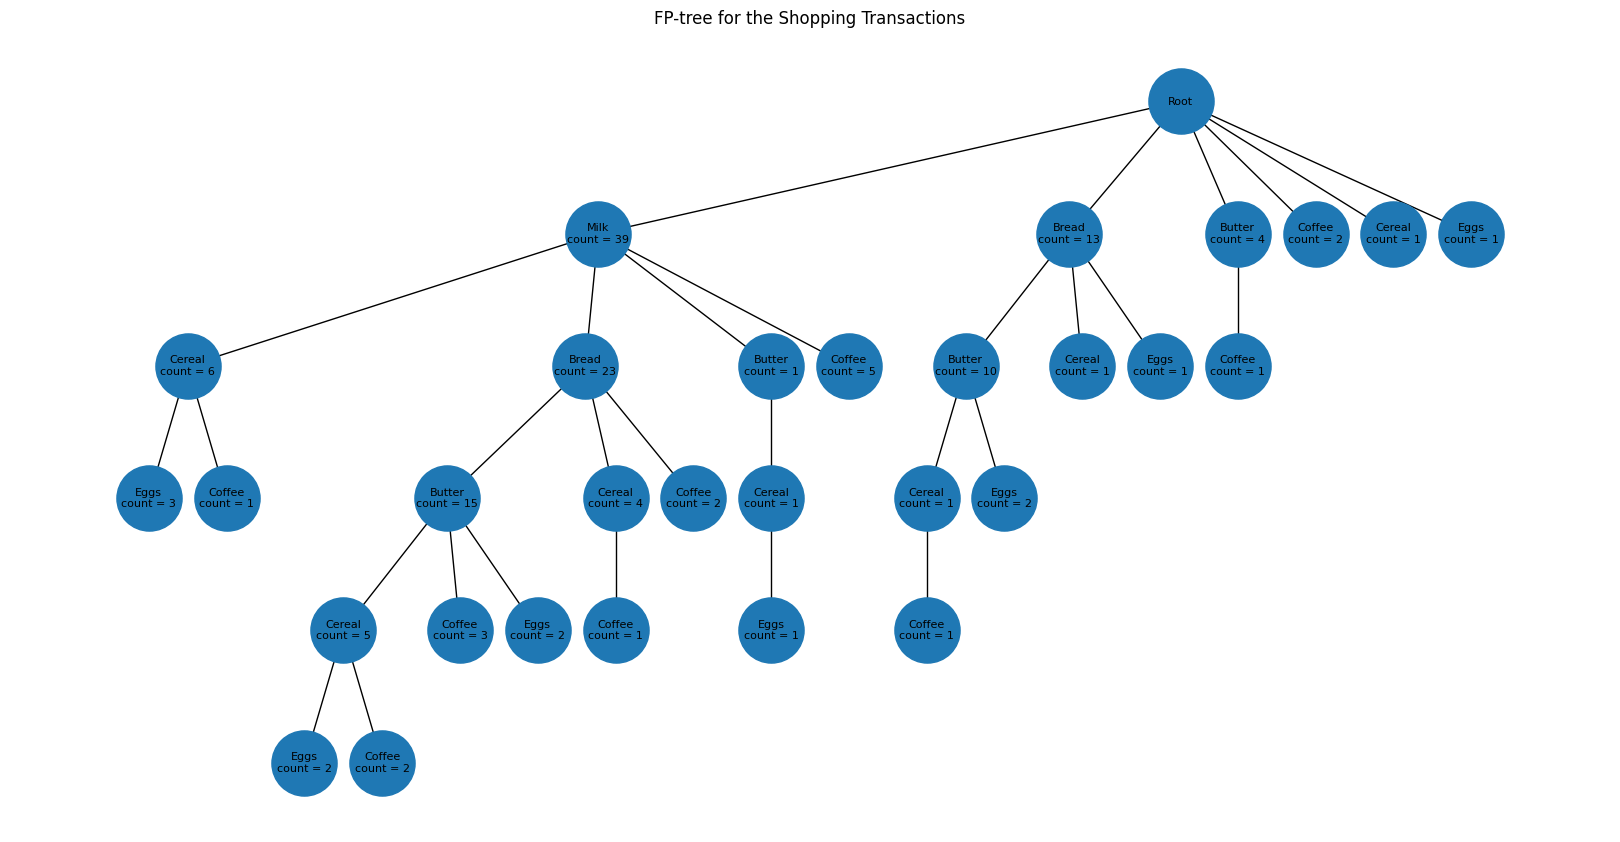

In [6]:
def new_tree_node():
    return {
        "count": 0,
        "children": {}
    }


def build_fp_tree(transactions):
    root = new_tree_node()

    for basket in transactions:
        current_node = root

        for item in basket:
            if item not in current_node["children"]:
                current_node["children"][item] = new_tree_node()

            current_node = current_node["children"][item]
            current_node["count"] += 1

    return root


def prepare_tree_graph(tree):
    graph = nx.DiGraph()
    labels = {"root": "Root"}
    positions = {}
    node_number = 0
    leaf_number = 0

    graph.add_node("root")

    def add_branch(tree_node, parent_id, depth):
        nonlocal node_number, leaf_number

        child_positions = []

        for item, child in tree_node["children"].items():
            node_number += 1
            child_id = f"node_{node_number}"

            graph.add_edge(parent_id, child_id)
            labels[child_id] = f"{item}\ncount = {child['count']}"

            child_x = add_branch(
                child,
                child_id,
                depth + 1
            )

            child_positions.append(child_x)

        if child_positions:
            x_position = sum(child_positions) / len(child_positions)
        else:
            x_position = leaf_number
            leaf_number += 1

        positions[parent_id] = (
            x_position,
            -depth
        )

        return x_position

    add_branch(tree, "root", 0)

    largest_x = max(
        position[0]
        for position in positions.values()
    )

    if largest_x > 0:
        positions = {
            node: (
                x / largest_x,
                y
            )
            for node, (x, y) in positions.items()
        }

    return graph, labels, positions


def draw_fp_tree(tree, title):
    graph, labels, positions = prepare_tree_graph(tree)

    plt.figure(figsize=(16, 8))

    nx.draw(
        graph,
        positions,
        labels=labels,
        with_labels=True,
        arrows=False,
        node_size=2200,
        font_size=8
    )

    plt.title(title)
    plt.axis("off")
    plt.show()


fp_tree = build_fp_tree(
    ordered_transactions
)

draw_fp_tree(
    fp_tree,
    "FP-tree for the Shopping Transactions"
)

### How to read the FP-tree

Start at the **Root** and follow a branch downward.

For example, a path such as:

```text
Root → Milk → Bread → Butter
```

shows transactions that contain those items in the global frequency order.

The number inside each node tells us how many transactions passed through that branch. A child count cannot be larger than its parent count.

## 6. Create a conditional pattern base

To find patterns that contain a specific item, FP-Growth collects the prefix paths that lead to that item.

The code below finds all prefix paths leading to **Butter**.

This is a simplified version of the step described as:

> Find frequent item list by creating a conditional tree.

In [7]:
def find_conditional_pattern_base(
    tree,
    target_item
):
    conditional_paths = []

    def walk(node, current_path):
        for item, child in node["children"].items():

            if item == target_item:
                if current_path:
                    conditional_paths.append(
                        (
                            current_path.copy(),
                            child["count"]
                        )
                    )

            walk(
                child,
                current_path + [item]
            )

    walk(tree, [])

    return conditional_paths


target_item = "Butter"

conditional_paths = find_conditional_pattern_base(
    fp_tree,
    target_item
)

conditional_pattern_table = pd.DataFrame([
    {
        "Prefix path": " → ".join(path),
        "Count": count
    }
    for path, count in conditional_paths
])

conditional_pattern_table

,Prefix path,Count
0,Milk → Bread,15
1,Milk,1
2,Bread,10


The conditional pattern base contains only the parts of the FP-tree that occur before Butter.

For example, a path such as `Milk → Bread` with count `15` means that the sequence occurred with Butter 15 times in the FP-tree.

## 7. Build and visualise the conditional tree for Butter

The conditional tree keeps only items that remain frequent within the prefix paths leading to Butter.

A conditional path may have a count larger than one. To keep the tree-building function simple, we repeat that path according to its count. This allows us to reuse the same `build_fp_tree()` function without introducing a separate weight parameter.

This repeated-path approach is suitable for this small teaching example. Large production implementations normally store the counts directly for efficiency.

Conditional item counts:
Counter({'Bread': 25, 'Milk': 16})


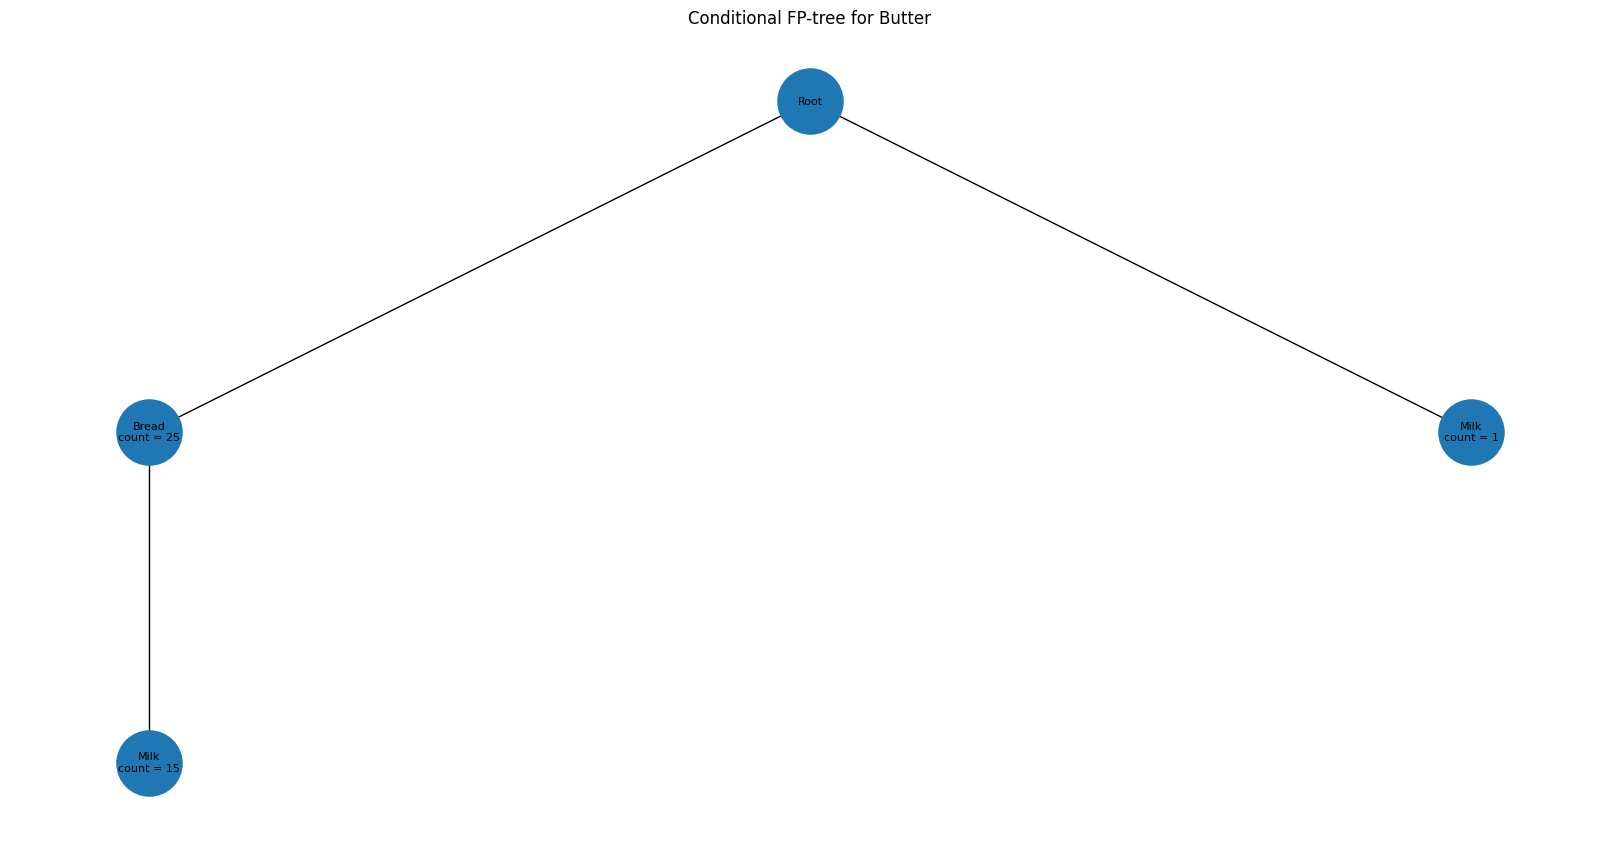

In [8]:
conditional_item_counts = Counter()

for path, path_count in conditional_paths:
    for item in path:
        conditional_item_counts[item] += path_count

conditional_frequent_items = {
    item: count
    for item, count in conditional_item_counts.items()
    if count >= minimum_count
}

conditional_order = sorted(
    conditional_frequent_items,
    key=lambda item: (
        -conditional_frequent_items[item],
        item
    )
)

conditional_rank = {
    item: position
    for position, item in enumerate(
        conditional_order
    )
}

conditional_transactions = []

for path, path_count in conditional_paths:
    filtered_path = [
        item
        for item in path
        if item in conditional_frequent_items
    ]

    filtered_path.sort(
        key=lambda item: conditional_rank[item]
    )

    # Repeat the path because it occurred path_count times.
    for repeat in range(path_count):
        if filtered_path:
            conditional_transactions.append(
                filtered_path.copy()
            )

butter_conditional_tree = build_fp_tree(
    conditional_transactions
)

print("Conditional item counts:")
print(conditional_item_counts)

draw_fp_tree(
    butter_conditional_tree,
    "Conditional FP-tree for Butter"
)

### Why the conditional-tree block is important

The conditional-tree block:

1. focuses on one target item;
2. collects only paths associated with that item;
3. removes items that are not frequent enough;
4. creates a smaller tree; and
5. helps discover frequent patterns containing the target item.

Without this step, FP-Growth would only compress the transactions into one tree. The conditional trees are what allow the algorithm to mine the frequent patterns.

## 8. Calculate frequent itemsets

To keep the practical easy to follow, the code below counts item combinations of one, two and three items.

The full FP-Growth algorithm discovers these combinations by recursively using conditional trees. This simple counter lets us inspect the support values directly.

In [9]:
itemset_counts = Counter()

for basket in transactions:
    unique_items = sorted(
        set(basket)
    )

    for itemset_size in range(1, 4):
        for itemset in combinations(
            unique_items,
            itemset_size
        ):
            itemset_counts[
                frozenset(itemset)
            ] += 1

frequent_itemsets = {
    itemset: count
    for itemset, count in itemset_counts.items()
    if (
        count / len(transactions)
        >= minimum_support
    )
}

frequent_itemsets_table = pd.DataFrame([
    {
        "Itemset": ", ".join(
            sorted(itemset)
        ),
        "Count": count,
        "Support": round(
            count / len(transactions),
            3
        )
    }
    for itemset, count in frequent_itemsets.items()
]).sort_values(
    ["Support", "Itemset"],
    ascending=[False, True]
)

frequent_itemsets_table.head(15)

,Itemset,Count,Support
2,Milk,39,0.650
4,Bread,36,0.600
5,Butter,30,0.500
6,"Bread, Butter",25,0.417
7,"Bread, Milk",23,0.383
0,Cereal,19,0.317
10,Coffee,18,0.300
8,"Butter, Milk",16,0.267
3,"Cereal, Milk",16,0.267
9,"Bread, Butter, Milk",15,0.250


## 9. Generate association rules

For a rule such as:

```text
IF Bread, THEN Butter
```

the measures are:

- **Support:** how often Bread and Butter occur together;
- **Confidence:** how often Butter occurs when Bread occurs; and
- **Lift:** how much more likely Butter is when Bread occurs compared with its normal occurrence.

A lift greater than `1` indicates a positive association.

In [10]:
minimum_confidence = 0.60
rules = []

for itemset, joint_count in frequent_itemsets.items():

    if len(itemset) < 2:
        continue

    for left_size in range(
        1,
        len(itemset)
    ):
        for left_items in combinations(
            sorted(itemset),
            left_size
        ):
            antecedent = frozenset(
                left_items
            )

            consequent = (
                itemset - antecedent
            )

            support = (
                joint_count
                / len(transactions)
            )

            confidence = (
                joint_count
                / itemset_counts[antecedent]
            )

            consequent_support = (
                itemset_counts[consequent]
                / len(transactions)
            )

            lift = (
                confidence
                / consequent_support
            )

            if confidence >= minimum_confidence:
                rules.append({
                    "IF": ", ".join(
                        sorted(antecedent)
                    ),
                    "THEN": ", ".join(
                        sorted(consequent)
                    ),
                    "Support": round(
                        support,
                        3
                    ),
                    "Confidence": round(
                        confidence,
                        3
                    ),
                    "Lift": round(
                        lift,
                        3
                    )
                })

rules_table = pd.DataFrame(rules).sort_values(
    ["Lift", "Confidence"],
    ascending=False
).reset_index(drop=True)

rules_table

,IF,THEN,Support,Confidence,Lift
0,"Butter, Milk",Bread,0.250,0.938,1.562
1,Butter,Bread,0.417,0.833,1.389
2,Bread,Butter,0.417,0.694,1.389
3,"Bread, Milk",Butter,0.250,0.652,1.304
4,Cereal,Milk,0.267,0.842,1.296
5,Coffee,Milk,0.233,0.778,1.197
6,Bread,Milk,0.383,0.639,0.983
7,"Bread, Butter",Milk,0.250,0.600,0.923


## 10. Interpret one rule

The following cell prints the strongest rule according to lift.

In [11]:
best_rule = rules_table.iloc[0]

print(
    "IF",
    best_rule["IF"],
    "THEN",
    best_rule["THEN"]
)

print(
    "Support:",
    best_rule["Support"]
)

print(
    "Confidence:",
    best_rule["Confidence"]
)

print(
    "Lift:",
    best_rule["Lift"]
)

IF Butter, Milk THEN Bread
Support: 0.25
Confidence: 0.938
Lift: 1.562


## Discussion forum guide

For Learning Activity 2, you can explain the conditional-tree code in your own words:

**What is the code doing?**

It selects one target item, finds the prefix paths that lead to that item, counts the items in those paths, removes infrequent items and constructs a smaller conditional FP-tree.

**Why is this block significant?**

It converts the compressed FP-tree into smaller item-specific trees. These conditional trees allow FP-Growth to discover frequent item combinations recursively and efficiently.

## Note about Learning Activity 1

Learning Activity 1 is a writing exercise. The seven travel-habit rules should be written as IF–THEN statements in a Word document rather than generated using this notebook.